In [1]:
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt

c:\Users\samny\anaconda3\envs\HLAN\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERT Models

In [2]:
### BlueBert
bluebert_tokenizer = AutoTokenizer.from_pretrained("bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12")
bluebert_model = AutoModel.from_pretrained("bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12")

### Bioclinical
bioclinical_tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bioclinical_model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

### BiomedRoberta
roberta_tokenizer = AutoTokenizer.from_pretrained("allenai/biomed_roberta_base")
roberta_model = AutoModel.from_pretrained("allenai/biomed_roberta_base")

### Data

In [3]:
train_data_path = "C:/Users/samny/NLP/HW_5/Data/train_50.csv"
dev_data_path = "C:/Users/samny/NLP/HW_5/Data/dev_50.csv"
test_data_path = "C:/Users/samny/NLP/HW_5/Data/test_50.csv"

print("Loading data:")
train_df = pd.read_csv(train_data_path)
dev_df = pd.read_csv(dev_data_path)
test_df = pd.read_csv(test_data_path)
print("Number of training notes:",len(train_df))
print("Number of validation notes:",len(dev_df))
print("Number of test notes:",len(test_df))

Loading data:
Number of training notes: 8066
Number of validation notes: 1573
Number of test notes: 1729


### Get Tokens

In [4]:
### Get doc rep for training, test and dev based on splitting into sentences
num_sent = 100
sent_len = 25
max_len = 2500
train_text = train_df['TEXT']
dev_text = dev_df['TEXT']
test_text = test_df['TEXT']

def split_note_chunks(text, window_size):
    note = text.split(' ')
    sentences = []
    for j in range(0, len(note), window_size):
        sentence = ' '.join(note[j:j+window_size])
        sentences.append(sentence)
    return sentences
train_doc_rep = []
for i in range(len(train_text)):
    text = train_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    train_doc_rep.append(sentences)
dev_doc_rep = []
for i in range(len(dev_text)):
    text = dev_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    train_doc_rep.append(sentences)
test_doc_rep = []
for i in range(len(test_text)):
    text = test_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    test_doc_rep.append(sentences)


In [26]:
def get_token_lens(train_rep, dev_rep, test_rep, tokenizer):
    token_len = []
    for sentences in train_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    for sentences in dev_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    for sentences in test_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    return token_len

In [27]:
bluebert_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, bluebert_tokenizer)
bioclinical_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, bioclinical_tokenizer)
roberta_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, roberta_tokenizer)

In [30]:
print(f'Bluebert max:{np.max(bluebert_token_len)}')
filtered_bluebert_len = [s for s in bluebert_token_len if s > 64]
print(f'Percent bluebert filtered out:{len(filtered_bluebert_len)/len(bluebert_token_len)*100}')
print(f'Bioclinical max:{np.max(bioclinical_token_len)}')
filtered_bioclinical_len = [s for s in bioclinical_token_len if s > 64]
print(f'Percent bioclinical filtered out:{len(filtered_bioclinical_len)/len(bioclinical_token_len)*100}')
print(f'Roberta max:{np.max(roberta_token_len )}')
filtered_roberta_len = [s for s in roberta_token_len  if s > 64]
print(f'Percent Roberta filtered out:{len(filtered_roberta_len)/len(roberta_token_len)*100}')

Bluebert max:174
Percent bluebert filtered out:0.1511570560241851
Bioclinical max:178
Percent bioclinical filtered out:0.4043131000646901
Roberta max:81
Percent Roberta filtered out:0.04147211600663554


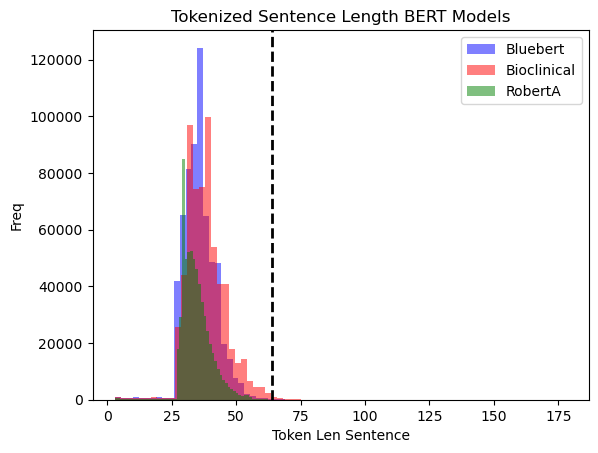

In [33]:
plt.hist(bluebert_token_len, bins = 75, alpha = 0.5, label = "Bluebert", color = 'blue')
plt.hist(bioclinical_token_len, bins = 75, alpha = 0.5, label = "Bioclinical", color = 'red')
plt.hist(roberta_token_len, bins = 75, alpha = 0.5, label = "RobertA", color = 'green')
plt.axvline(x=64, color='black', linestyle='--', linewidth=2)
plt.xlabel('Token Len Sentence')
plt.ylabel('Freq')
plt.title('Tokenized Sentence Length BERT Models')
plt.legend()
plt.show()

In [12]:
### Get doc rep for training, test and dev based on splitting into sentences
num_sent = 100
sent_len = 25
max_len = 2500
train_text = train_df['TEXT']
dev_text = dev_df['TEXT']
test_text = test_df['TEXT']

def split_note_chunks(text, window_size):
    note = text.split(' ')
    sentences = []
    for j in range(0, len(note), window_size):
        sentence = ' '.join(note[j:j+window_size])
        sentences.append(sentence)
    return sentences
train_doc_rep = []
for i in range(len(train_text)):
    text = train_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    train_doc_rep.append(sentences)

In [13]:
### Get tokens
train_tokenized = []
train_mask = []
for note in train_doc_rep:
    tokens = []
    mask = []
    for sentences in note:
        encoding = bioclinical_tokenizer(sentences, padding = 'max_length', max_length = 64,truncation = True, return_tensors = 'pt')
        input_ids = encoding['input_ids']
        attention_mask = encoding['attention_mask']
        tokens.append(input_ids)
        mask.append(attention_mask)
    tokens = torch.cat(tokens, dim = 0)
    mask = torch.cat(mask, dim = 0)
    train_tokenized.append(tokens)
    train_mask.append(mask)

In [9]:
### apply padding

In [14]:
train_padded = []
for note in train_tokenized:
    if note.shape[0] > num_sent:
        train_padded.append(note[:num_sent,:])
    elif note.shape[0] == num_sent:
        train_padded.append(note)
    else:
        pad_dim = num_sent - note.shape[0]
        padded_note = F.pad(note,(0, 0, 0, pad_dim))
        train_padded.append(padded_note)

In [15]:
train_tokenized[-1].shape

torch.Size([303, 64])

In [16]:
train_padded = torch.stack(train_padded)
train_padded.shape

torch.Size([8066, 100, 64])

In [13]:
train_tokenized[0]

tensor([[  101, 10296,  2236, 12398,  2236,  2236,  1104,  3485,  2673,   182,
          1555,  1607,  1104,  1103,  1675,  6946,  1142,  1110,   170,  1214,
          1385,  1299,  1114,   170,  1607,  1104,   176, 26601, 15177,   124,
          1161,  1119,  4163, 27659,   172,  6272,  6704,  1105,   172,  3161,
          1197, 15342,  1548, 13306,  1231,  7050, 22233,  9435, 23864,   177,
         24312, 23826,  1988,  1114,  2967,  2704, 20412,  3718,  1106, 13522,
          1104,   172,  3161,  1197, 15342,  1548,  1150,  8218,  1114,  1519,
          7111,  4873,  1105,  1114,  1141,  2004,  1104, 23123,  2193,  6801,
          1548,  1103,  5351,  3756,  1136,  2296,  1218,  1111,  1103,  1763,
          1160,  1106,  1210,  1552,  1119,  4856,  2296, 18418,  1181,   102],
        [  101,   173,   189,  2261,  2261,  1295,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0, 

In [17]:
train_mask_padded = []
for note in train_mask:
    if note.shape[0] > num_sent:
        train_mask_padded.append(note[:num_sent,:])
    elif note.shape[0] == num_sent:
        train_mask_padded.append(note)
    else:
        pad_dim = num_sent - note.shape[0]
        padded_note = F.pad(note,(0, 0, 0, pad_dim))
        train_mask_padded.append(padded_note)

In [18]:
train_mask_padded = torch.stack(train_mask_padded)
train_mask_padded.shape

torch.Size([8066, 100, 64])

### Function to get tokens

In [27]:
def split_note_chunks(text, window_size):
    note = text.split(' ')
    sentences = []
    for j in range(0, len(note), window_size):
        sentence = ' '.join(note[j:j+window_size])
        sentences.append(sentence)
    return sentences

def tokenize_bert_and_pad(input_text = None, sent_len = None, num_sent = None, tokenizer = None, max_length_tokens = None):
    doc_rep = []
    n_notes = len(input_text)

    for i in range(n_notes):
        text = input_text.iloc[i]
        sentences = split_note_chunks(text, window_size = sent_len)
        doc_rep.append(sentences)
    
    token_list = []
    attn_mask_list = []

    for note in doc_rep:
        tokens = []
        masks = []
        for sentences in note:
            encoding = tokenizer(sentences, padding = 'max_length', max_length = max_length_tokens, truncation = True, return_tensors = 'pt')
            input_ids = encoding['input_ids']
            attention_mask = encoding['attention_mask']
            tokens.append(input_ids)
            masks.append(attention_mask)
        tokens = torch.cat(tokens, dim = 0)
        masks = torch.cat(masks, dim = 0)
        token_list.append(tokens)
        attn_mask_list.append(masks)

    token_padded = []
    for note in token_list:
        if note.shape[0] > num_sent:
            token_padded.append(note[:num_sent,:])
        elif note.shape[0] == num_sent:
            token_padded.append(note)
        else:
            pad_dim = num_sent - note.shape[0]
            padded_note = F.pad(note,(0, 0, 0, pad_dim))
            token_padded.append(padded_note)
    mask_padded = []
    for note in attn_mask_list:
        if note.shape[0] > num_sent:
            mask_padded.append(note[:num_sent,:])
        elif note.shape[0] == num_sent:
            mask_padded.append(note)
        else:
            pad_dim = num_sent - note.shape[0]
            padded_note = F.pad(note,(0, 0, 0, pad_dim))
            mask_padded.append(padded_note)
    
    token_tensor = torch.stack(token_padded)
    attn_mask_tensor = torch.stack(mask_padded)

    return token_tensor, attn_mask_tensor

In [29]:
train_tokens.shape

torch.Size([8066, 25, 256])

### Test embeddings in model training pass:

In [19]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
#from gensim.models import Word2Vec
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import f1_score,roc_auc_score
import gc
import random
import os
# import torch.nn.functional as F

class BERT_HLAN(nn.Module):
    def __init__(self, num_sent, bert_model, code_weight_tensor,embed_dim, hidden_size, dropout_prob, freeze_embed = True, use_label_embeddings=True, num_classes=50):
        super(BERT_HLAN, self).__init__()
        self.num_sent = num_sent
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.dropout_prob = dropout_prob
        self.use_label_embeddings = use_label_embeddings
        self.num_classes = num_classes

        self.bert_model = bert_model

        if freeze_embed:
            for param in self.bert_model.parameters():
                param.requires_grad = False

        self.gru_w = nn.GRU(input_size = embed_dim, hidden_size = hidden_size, bidirectional=True, batch_first=True)
        self.W_w = nn.Linear(hidden_size*2, hidden_size*2)
        self.attn_tanh = nn.Tanh()
        self.V_w_l = nn.Parameter(torch.randn(50, hidden_size*2))
        self.word_softmax = nn.Softmax(dim = 2)

        self.gru_s = nn.GRU(input_size = hidden_size * 2, hidden_size = hidden_size * 2, bidirectional = True, batch_first = True)
        self.W_s = nn.Linear(hidden_size * 4, hidden_size * 2)
        self.V_s_l = nn.Parameter(torch.randn(50, hidden_size *2))
        self.drop_layer = nn.Dropout(p = dropout_prob)
        self.sentence_softmax = nn.Softmax(dim =2)

        if self.use_label_embeddings:
            self.W_projection = nn.Parameter(code_weight_tensor, requires_grad=not freeze_embed)
        else:
            # Initialize with Xavier (Glorot) uniform as in TensorFlow’s default initializer
            self.W_projection = nn.Parameter(torch.empty(num_classes,hidden_size * 4))
            nn.init.xavier_uniform_(self.W_projection)

        self.sigmoid_act = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.view(-1, input_ids.shape[2])
        attention_mask = attention_mask.view(-1, attention_mask.shape[2])
        embed_comp = self.bert_model(input_ids = input_ids, attention_mask = attention_mask)
        last_hidden_state = embed_comp.last_hidden_state
        print(last_hidden_state.shape)
        #last_hidden_state_reshape = last_hidden_state.view(-1, self.num_sent, input_ids.shape[1], 768)
        #embed_comp_reshape = last_hidden_state.view(-1, last_hidden_state.shape[2], last_hidden_state.shape[3])
        C_s_l = self.word_attention(last_hidden_state)
        #C_s_l = self.word_attention(embed_comp_reshape)

        doc_rep = self.sentence_attention(C_s_l)

        logits = self.apply_final_layer(doc_rep)

        probs = self.sigmoid_act(logits)

        return probs

    def word_attention(self, X):
        hidden_state, hnn = self.gru_w(X)
        hidden_state_reshape = hidden_state.reshape(-1,hidden_state.size(-1))
        hidden_rep_step = self.attn_tanh(self.W_w(hidden_state_reshape))
        v = hidden_rep_step.reshape(-1, hidden_state.size(1),hidden_state.size(-1))

        a_w_l = torch.matmul(v,self.V_w_l.T).permute(2, 0, 1)
        a_w_l = self.word_softmax(a_w_l).unsqueeze(3)
        C_s_l = a_w_l*hidden_state
        C_s_l = torch.sum(C_s_l,dim = 2)

        return C_s_l

    def sentence_attention(self, X):
        X_reshape = X.transpose(0, 1)
        S_l, hnn = self.gru_s(X_reshape)

        hidden_rep_step = self.attn_tanh(self.W_s(S_l))
        hidden_rep_reshape = hidden_rep_step.view(-1, self.num_sent, hidden_rep_step.size(1), hidden_rep_step.size(2))
        U = hidden_rep_reshape.permute(2, 0, 1, 3)

        S_l_reshape = S_l.view(-1, self.num_sent, S_l.size(1), S_l.size(2))
        S_l_reshape = S_l_reshape.permute(2, 0, 1, 3)
        V_s_l_expand = self.V_s_l.unsqueeze(1).unsqueeze(1)
        attention_logits = (U * V_s_l_expand).sum(dim=3)
        p_attention_sent = self.sentence_softmax(attention_logits - attention_logits.max(dim=2, keepdim=True).values)
        document_representation = (p_attention_sent.unsqueeze(3) * S_l_reshape).sum(dim=2)
        
        return document_representation

    def apply_final_layer(self, doc_rep):
        drop_step = self.drop_layer(doc_rep) 
        drop_step_reshape = drop_step.permute(1,2,0)
        logits = drop_step_reshape * self.W_projection.T
        logits = logits.sum(dim = 1)

        return logits

In [20]:
def train_model(model, train_dataloader,optimizer, loss_fn, num_epochs, device):
    train_loss = list()
    dev_micro_f1, dev_macro_f1, dev_micro_auroc,dev_macro_auroc = list(),list(),list(),list()
    for epoch in range(num_epochs):
        print('Epoch: '+str(epoch))
        model.train()
        epoch_loss = 0
        n = 0
        for batch in tqdm(train_dataloader):
        # for batch in train_dataloader:
            n += 1
            inputs, attn_mask, targets = batch
            print(inputs.shape,attn_mask.shape)
            inputs, attn_mask, targets = inputs.to(device), attn_mask.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, attn_mask)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()

            inputs.detach().cpu()
            targets.detach().cpu()
            outputs.detach().cpu()
            attn_mask.detach().cpu()
            loss.detach().cpu()
            epoch_loss += loss.item()

            del batch, inputs, targets, outputs, loss, attn_mask

            if str(device).startswith('cuda'):
                with torch.cuda.device(device):
                    torch.cuda.empty_cache()
                    gc.collect()
        
        print(epoch_loss / n)
        train_loss.append(epoch_loss)
        #epoch_dev_micro_f1, epoch_dev_macro_f1, epoch_dev_micro_auroc,epoch_dev_macro_auroc = evaluate_model(model, dev_dataloader, calibration, device)
        #print(f'Micro F1 Score: {epoch_dev_micro_f1:.4f}')
        #print(f'Macro F1 Score: {epoch_dev_macro_f1:.4f}')
        #print(f'Micro AUROC : {epoch_dev_micro_auroc:.4f}')
        #print(f'Macro AUROC: {epoch_dev_macro_auroc:.4f}')
        #dev_micro_f1.append(epoch_dev_micro_f1)
        #dev_macro_f1.append(epoch_dev_macro_f1)
        #dev_micro_auroc.append(epoch_dev_micro_auroc)
        #dev_macro_auroc.append(epoch_dev_micro_auroc)
    return train_loss#, dev_micro_f1,dev_macro_f1,dev_micro_auroc,dev_macro_auroc

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
hidden_size = 100
embed_dim = 768
dropout_prob = 0.5
batch_size = 2
lr = 0.001
l2 = 0.001
calibration = 0.5
num_epochs = 2
use_label_embeddings = True
freeze_emb = False

code_model_path = "C:/Users/samny/NLP/HW_3/Embeddings/code_model_weights.pt"
train_y_path = "C:/Users/samny/NLP/HW_3/Embeddings/train_code-emb.pt"
train_y = torch.load(train_y_path, weights_only = True).float()
code_weight_tensor = torch.load(code_model_path, weights_only=True)

In [23]:
model = BERT_HLAN(num_sent = 100, bert_model = bioclinical_model, code_weight_tensor=code_weight_tensor, embed_dim=embed_dim, hidden_size=hidden_size, dropout_prob=dropout_prob, freeze_embed = False)
model.to(device)

BERT_HLAN(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [24]:
from torch.utils.data import Dataset, DataLoader, TensorDataset
train_dataset = TensorDataset(train_padded[:4], train_mask_padded[:4], train_y[:4])
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

In [25]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = l2)
train_loss= train_model(model, train_dataloader, optimizer, loss_fn, num_epochs, device)

Epoch: 0


  0%|          | 0/2 [00:00<?, ?it/s]

torch.Size([2, 100, 64]) torch.Size([2, 100, 64])
torch.Size([200, 64, 768])


 50%|█████     | 1/2 [00:29<00:29, 29.93s/it]

torch.Size([2, 100, 64]) torch.Size([2, 100, 64])
torch.Size([200, 64, 768])


...

torch.Size([2, 100, 64]) torch.Size([2, 100, 64])
torch.Size([200, 64, 768])


 50%|█████     | 1/2 [00:29<00:29, 29.65s/it]

torch.Size([2, 100, 64]) torch.Size([2, 100, 64])
torch.Size([200, 64, 768])


100%|██████████| 2/2 [00:59<00:00, 29.62s/it]

0.3641533702611923
